# 02｜卷积核与池化：CNN 怎样观察局部区域？

本页仍不训练模型。先用人工卷积核观察确定性的图像变化，再理解可学习卷积层。

In [1]:
%matplotlib inline
from pathlib import Path
import sys

LAB_DIR = Path.cwd()
if not (LAB_DIR / "cnn_lab").is_dir():
    LAB_DIR = (LAB_DIR / "02_cnn_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

from cnn_lab import load_digits_data, show_convolution

## 1｜一个输出位置怎样计算

对单通道图片，卷积可以直观写成：

$$
Y_{i,j}=\sum_{u=0}^{K-1}\sum_{v=0}^{K-1}X_{i+u,j+v}W_{u,v}+b
$$

在 $(i,j)$ 附近取一个 $K\times K$ 局部窗口，与卷积核 $W$ 逐元素相乘并求和。

$$
H_{\mathrm{out}}=\left\lfloor\frac{H+2P-K}{S}\right\rfloor+1
$$

$K$ 是 kernel size，$P$ 是 padding，$S$ 是 stride。8×8 图片使用 $K=3,P=1,S=1$，输出仍为 8×8；再经过 2×2 Pooling 后变成 4×4。

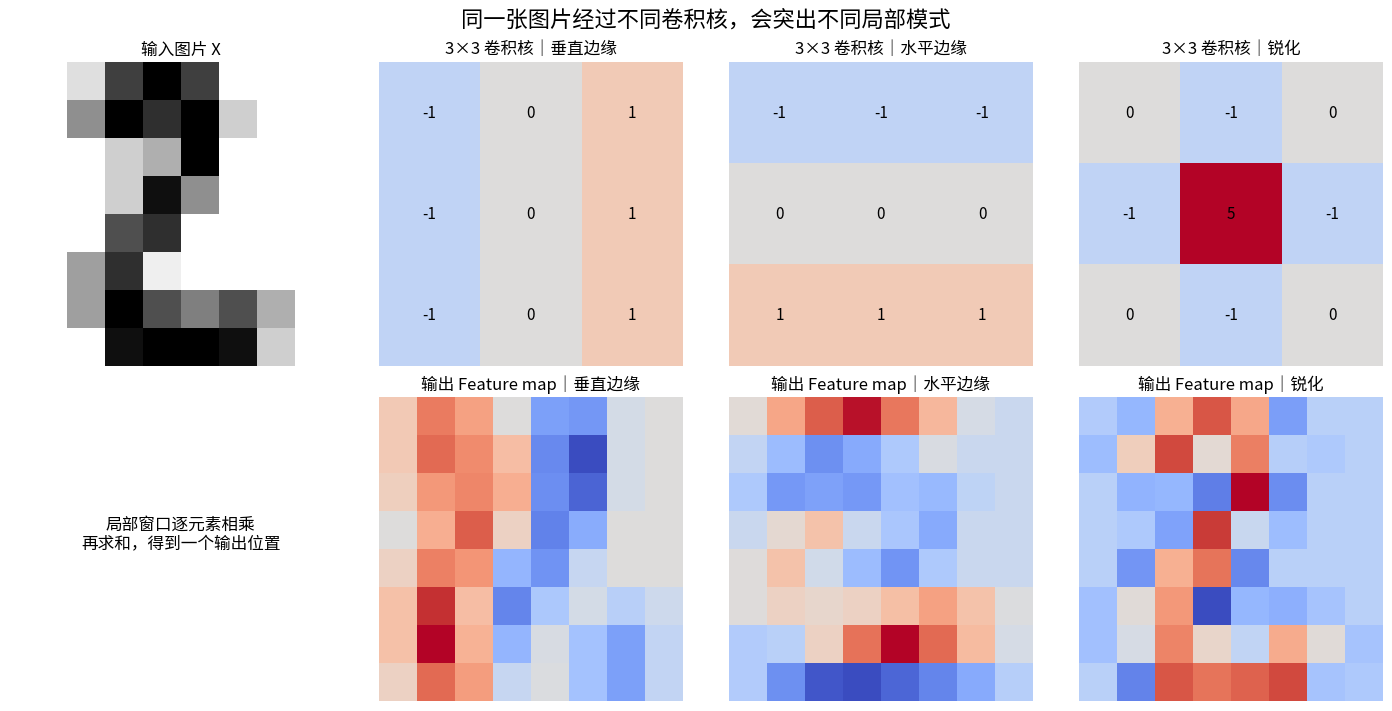

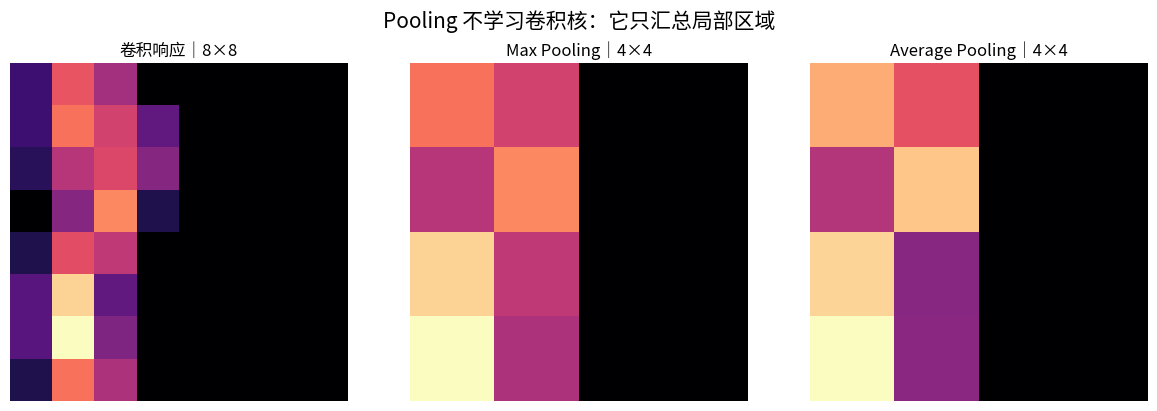

In [2]:
data = load_digits_data(seed=42)
convolution_figure, pooling_figure = show_convolution(data)

## 2｜看图顺序

1. 先看输入数字的主要笔画；
2. 再看三个 3×3 卷积核中正负权重的位置；
3. 比较输出 Feature map 哪些区域响应更强；
4. 比较 Max 与 Average Pooling 保留的信息。

**预测问题：**同一个卷积核为什么可以检测图片不同位置的相似局部模式？

<details><summary>参考答案</summary>
因为同一组卷积核权重会滑过整张图片，这叫 Weight sharing（权重共享）。参数不会为每个位置单独复制。
</details>

人工卷积核可以被命名为边缘或锐化；训练得到的卷积核不一定对应一个固定的人类概念。

## 完成本页后：释放资源并结束内核

运行下面的最后一个单元格。它会依次清空变量、关闭图片、释放未使用的 CUDA 缓存，并向 Jupyter 内核发送正常关机请求。

运行后，VS Code 可能显示“内核已停止”“请选择内核”或暂时断开连接，这是正常现象，表示当前 Notebook 的 Python 进程已经结束。再次实验时，重新选择 Python 内核即可。

In [3]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()

# 先释放当前进程中未使用的 CUDA 缓存。
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("清理完成，正在结束当前 Notebook 的 Python 内核……")

# 正常关闭当前 Jupyter 内核；再次运行时需要重新选择内核。
get_ipython().kernel.do_shutdown(restart=False)


清理完成，正在结束当前 Notebook 的 Python 内核……


{'status': 'ok', 'restart': False}